In [1]:
import pandas as pd
from operator import attrgetter
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors

## Подготовка данных

In [3]:
orders = pd.read_csv('olist_orders_dataset.csv')

In [4]:
order_items = pd.read_csv('olist_order_items_dataset.csv')

In [5]:
customers = pd.read_csv('olist_customers_dataset.csv')

In [6]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [7]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [8]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [9]:
# Проверяем наличие незаполненных данных
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

## Задача 1. Рассчитаем retention
для заказов со статусом "delivered" по уникальному id пользователя

In [11]:
# Отбираем только те заказы, которые были доставлены
delivered_orders = orders.query('order_status == "delivered"')

In [12]:
# Объединяем таблицу с доставленными заказами и данными по клиентам, объединяем по данным таблицы доставленных заказов
merged_data = pd.merge(delivered_orders, customers, on = 'customer_id', how = 'left')

In [13]:
# Приводим данные к формату datetime
merged_data['order_purchase_timestamp'] = pd.to_datetime(merged_data['order_purchase_timestamp'])

In [14]:
# Извлекаем месяц и день заказа
merged_data['order_period'] = merged_data['order_purchase_timestamp'].dt.to_period('M')
merged_data['order_period_day'] = merged_data['order_purchase_timestamp'].dt.to_period('D')

In [15]:
# Присваиваем когорты на основе даты первого создания заказа для уникального id пользователя, а потом
# для каждого берем все столбцы с датой и определяем минимальный (первый). В Первом случае выносим месяц, во втором - день
merged_data['cohort'] = merged_data.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
merged_data['cohort_day'] = merged_data.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('D')

In [16]:
# Рассчитываем номер периода в днях (месячные периоды, значит, делим на 30)
merged_data['period_number_month'] = np.floor((merged_data.order_period_day - merged_data.cohort_day).apply(attrgetter('n')) / 30)

In [17]:
# Агрегируем данные по когортам и рассчитанному номеру периода (в месяцах)
df_cohort = merged_data.groupby(['cohort', 'period_number_month']).agg(n_customers=('customer_unique_id', 'nunique')).reset_index()

In [18]:
# Создаем сводную таблицу для когортного анализа
cohort_pivot = df_cohort.pivot_table(index='cohort', columns='period_number_month', values='n_customers')

In [19]:
cohort_pivot.head()

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,...,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,1.0,1.0
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,NaN,4.0,1.0,1.0,2.0,2.0,NaN,NaN,...,4.0,3.0,2.0,NaN,2.0,2.0,2.0,1.0,NaN,NaN
2017-02,1628.0,2.0,3.0,6.0,4.0,2.0,4.0,1.0,2.0,4.0,...,6.0,1.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN,NaN


In [20]:
# Рассчитываем размеры когорт (первый столбец сводной таблицы)
cohort_size = cohort_pivot.iloc[:, 0]

In [21]:
# Вычисляем коэффициенты удержания, деля на размер когорты
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

In [22]:
retention_matrix.head()

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,...,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.003817,0.003817
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002789,NaN,0.005579,0.001395,0.001395,0.002789,0.002789,NaN,NaN,...,0.005579,0.004184,0.002789,NaN,0.002789,0.002789,0.002789,0.001395,NaN,NaN
2017-02,1.0,0.001229,0.001843,0.003686,0.002457,0.001229,0.002457,0.000614,0.001229,0.002457,...,0.003686,0.000614,0.001843,0.001229,0.000614,0.000614,0.001843,NaN,NaN,NaN


### Помесячный retention

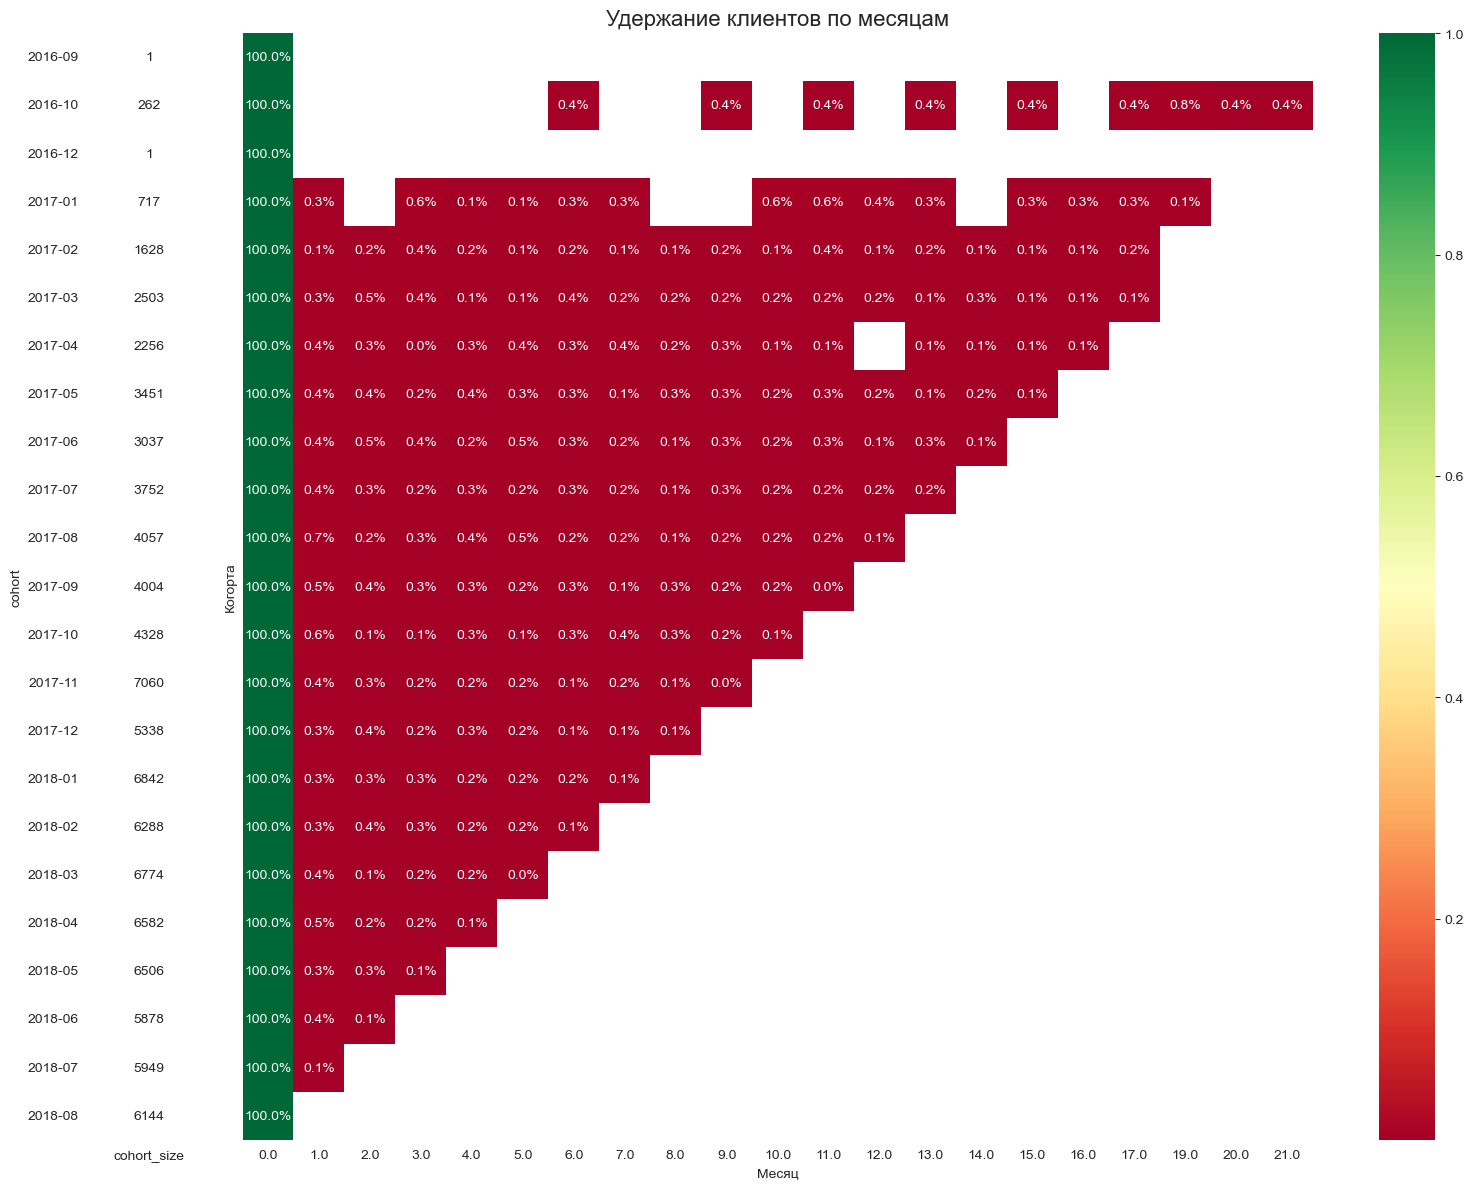

In [24]:
# Строим тепловую карту когортного анализа
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.1%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Удержание клиентов по месяцам', fontsize=16)
    ax[1].set(xlabel='Месяц', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

### Медианный retention 1-го месяца:

In [26]:
# Выводим retention 1 месяца в отдельный датафрейм
cohort_1_month = retention_matrix.iloc[:, 1]

In [27]:
# Рассчитаем медианный retention первого месяца
median_1m = round(cohort_1_month.dropna().median(),4)
print("Медианный retention 1-го месяца:", median_1m)

Медианный retention 1-го месяца: 0.0035


### Когорта с самым высоким retention за 3 месяц

In [29]:
# Выводим retention 3 месяца в отдельный датафрейм
cohort_3_month = retention_matrix.iloc[:, 3]

In [30]:
# находим индекс (название когорты) максимального ретеншна за 3 месяц
cohort_max_retention_3m = cohort_3_month.idxmax().strftime('%Y-%m')
print("Когорта с самым высоким retention за 3 месяц:", cohort_max_retention_3m)

Когорта с самым высоким retention за 3 месяц: 2017-01


## Задача 2. Определим, существует ли product/market fit у маркетплейса.

Оценим, насколько хорошо продукт закрывает потребности клиента. До сих пор непонятно, можно ли масштабировать подобный продукт на новые рынки. Есть вероятность, что маркетплейс будет приносить убытки.

### Наличие product/market fit у данного продукта с помощью когортного анализа:

Поскольку мы видим на тепловой карте, что после того как мы привлекли клиента в первый месяц, их удержание для каждой когорты меньше 1% (резкое падение), то это свидетельствует о низком retention.   
Для когорты 2016-09 и 2016-12 в следующие месяцы не вернулся ни один клиент, и это означает, что какие-то потребности пользователя не удовлетворяются.   
Визуализируем отсутствие PMF на примере когорты 2017_02

In [34]:
cohort_2017_02 = retention_matrix.iloc[4, :].iloc[1:]

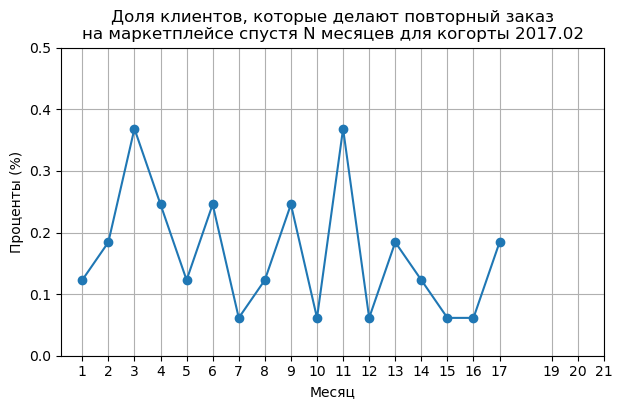

In [35]:
# рисуем график для определения PMF по когорте 2017_02
plt.figure(figsize=(7, 4))
plt.plot(cohort_2017_02.index, cohort_2017_02.values * 100, marker='o')
plt.title('Доля клиентов, которые делают повторный заказ\nна маркетплейсе спустя N месяцев для когорты 2017.02')
plt.xlabel('Месяц')
plt.ylabel('Проценты (%)')
plt.xticks(cohort_2017_02.index)
plt.grid()
plt.ylim(0, 0.5)
plt.show()

### Причины отсутствия PMF:
    - Сложность получения заказа (мало ПВЗ, клиенту далеко идти, не удобно)
    - Низкое качество товара и условий перевозки (малое количество складов, плохие условия хранения, товар испортился и пришел в нетоварном виде)
    - Длительный цикл доставки (проходит очень много времени от процесса оплаты до получения, так как товар идет из Бразилии, международная логистика усложняет процесс доставки + таможенное оформление)
    - Узкая направленность товаров (товары из Бразилии - возможно, ассортимент товара довольно нишевой, поэтому продукты не пользуются спросом)
    - Уровень сервиса в пунктах доставки или в процессе оформления (возможно, был негативный опыт, из-за которого клиенты не хотят возвращаться)

### Задача 3. Определим 5 основных метрик, чтобы максимизировать прибыль компании

Сформулируем продуктовые метрики маркетплейса, чтобы компания могла на них ориентироваться.

В первую очередь необходимо:

Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

Первая метрика должна отражать рост объёма продаж маркетплейса.  
Вторая — показывать объем аудитории, которой продукт доставляет ценность.  
Третья — отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных). 
Четвёртая — отражать вовлеченность клиента в продолжение использования продукта.  
Пятая — отражать денежное выражение вовлеченности клиента.   
Визуализируйте первую, вторую, четвёртую и пятую метрики. Используйте месячную гранулярность и окно в 1 месяц, если это нужно.

### Первая метрика :: выручка
отражает рост объёма продаж маркетплейса

In [39]:
# объединяем таблицу с доставленными заказами и данными по их содержимому
all_order_products = pd.merge(delivered_orders, order_items, on = 'order_id', how = 'left')

In [40]:
all_order_products.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [244]:
# Приводим данные момента подтверждения оплаты (т.е. получение денег маркетплейсом) к формату datetime
all_order_products['order_approved_at'] = pd.to_datetime(merged_data['order_approved_at'])
# Извлекаем месяц заказа
all_order_products['payment_period'] = all_order_products['order_approved_at'].dt.to_period('M')

In [246]:
# считаем выручку по месяцам по тем заказам, по которым было подтверждение оплаты
revenue_approved_payment = all_order_products.groupby('payment_period', as_index = False).price.sum() \
                                             .rename(columns = {'price' : 'revenue'})

In [248]:
revenue_approved_payment.head()

,payment_period,revenue
0,2016-09,135.00
1,2016-10,30389.70
2,2016-12,114.00
3,2017-01,85169.68
4,2017-02,195822.65


Предполагаем, что аналогично другим маркетплейсам. те заказы, по которым не пришло подтверждение оплаты до доставки, были оплачены после получения, поэтому посчитаем суммы выручки после доставки заказа

In [45]:
# Приводим данные момента доставки заказа к формату datetime. 
# Берем shipping_limit_date, так как в фактической дате доставки очень много пропусков, т.е.данные скорее всего 
# не записаны, но раз товар в статусе delivered, то по факту деньги должны быть получены
all_order_products['shipping_limit_date'] = pd.to_datetime(all_order_products['shipping_limit_date'])
# Извлекаем месяц доставки заказа
all_order_products['delivery_period'] = all_order_products['shipping_limit_date'].dt.to_period('M')

# Считаем выручку по месяцам по дате доставки без подтверждения оплаты
revenue_delivered_payment = all_order_products.query('order_approved_at.isna()').groupby('delivery_period', as_index = False) \
                                              .price.sum() \
                                              .rename(columns = {'price' : 'd_revenue', 'delivery_period' : 'payment_period'})

In [174]:
# преобразуем данные даты из object в datetime
all_order_products['order_purchase_timestamp'] = pd.to_datetime(all_order_products['order_purchase_timestamp'])
all_order_products['order_approved_at'] = pd.to_datetime(all_order_products['order_approved_at'])
all_order_products['order_delivered_carrier_date'] = pd.to_datetime(all_order_products['order_delivered_carrier_date'])
all_order_products['order_delivered_customer_date'] = pd.to_datetime(all_order_products['order_delivered_customer_date'])
all_order_products['order_estimated_delivery_date'] = pd.to_datetime(all_order_products['order_estimated_delivery_date'])

In [47]:
# проверяю, за какой последний день у нас есть данные по времени доставки товара, 
# чтобы понимать, по какой месяц можно отражать выручку, т.е. за какой период есть данные
all_order_products.order_delivered_customer_date.max()

Timestamp('2018-10-17 13:22:46')

Продолжаем считать, что у нас может быть выручка до 2018-10

In [49]:
revenue_delivered_payment

,payment_period,d_revenue
0,2016-10,5858.01
1,2017-01,10893.35
2,2017-02,30132.36
3,2017-03,37403.99
4,2017-04,41060.98
5,2017-05,52230.68
6,2017-06,55139.18
7,2017-07,54893.50
8,2017-08,70361.58
9,2017-09,74150.31


In [50]:
# объединяем таблицы с выручкой по дате оплаты и дате доставки
revenue = pd.merge(revenue_approved_payment, revenue_delivered_payment, on = 'payment_period', how = 'outer')
# избавляемся от Nan
revenue.fillna(0, inplace=True)
# считаем общую выручку
revenue['all_revenue'] = revenue.revenue + revenue.d_revenue
revenue.head()

,payment_period,revenue,d_revenue,all_revenue
0,2016-09,135.00,0.00,135.00
1,2016-10,30389.70,5858.01,36247.71
2,2016-12,114.00,0.00,114.00
3,2017-01,85169.68,10893.35,96063.03
4,2017-02,195822.65,30132.36,225955.01


In [256]:
revenue

,payment_period,revenue,d_revenue,all_revenue
0,2016-09,135.00,0.00,135.00
1,2016-10,30389.70,5858.01,36247.71
2,2016-12,114.00,0.00,114.00
3,2017-01,85169.68,10893.35,96063.03
4,2017-02,195822.65,30132.36,225955.01
5,2017-03,300031.00,37403.99,337434.99
6,2017-04,259925.26,41060.98,300986.24
7,2017-05,439977.96,52230.68,492208.64
8,2017-06,364198.88,55139.18,419338.06
9,2017-07,461508.90,54893.50,516402.40


In [258]:
revenue_2 = revenue.copy()

### Выручка

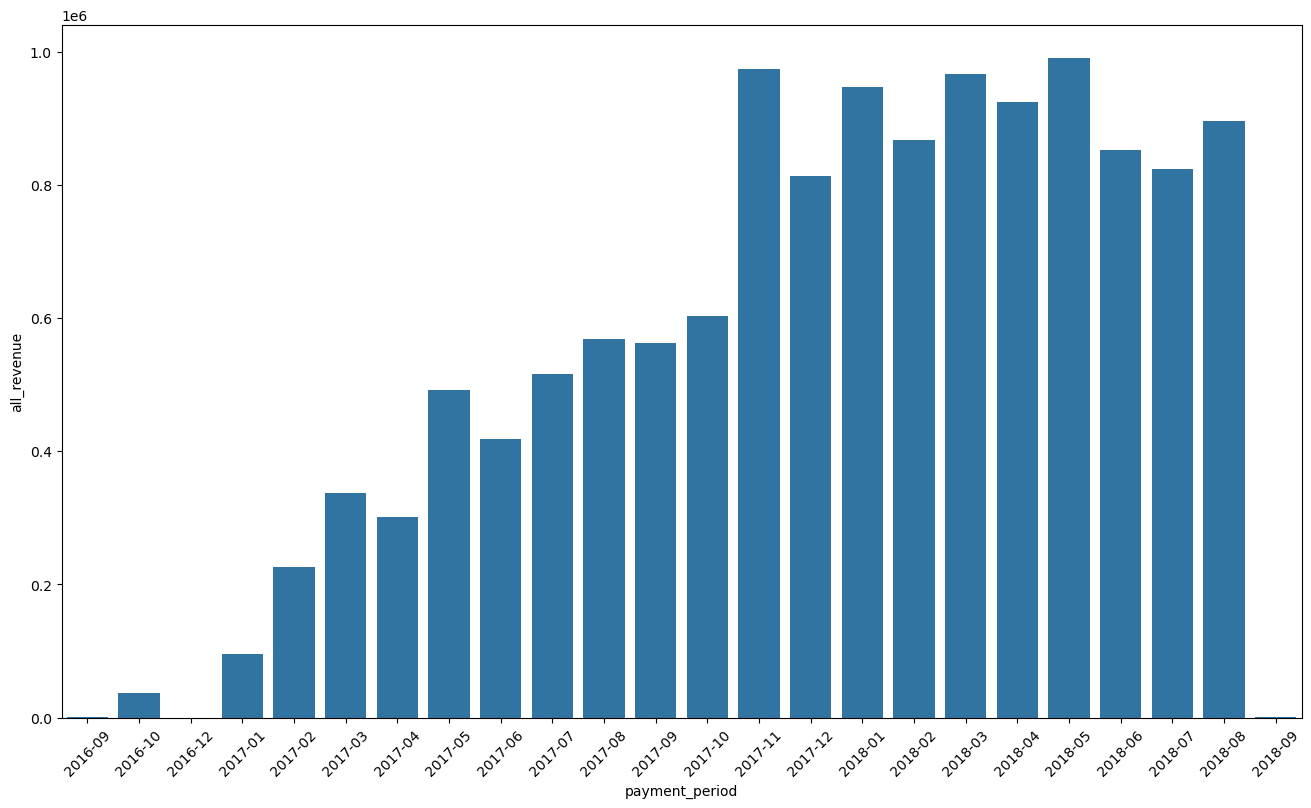

In [218]:
# рисуем график выручки
plt.figure(figsize=(16, 9))
sns.barplot(data=revenue, x ='payment_period', y ='all_revenue')
plt.xticks(rotation=45)
plt.show()

### Вторая метрика 

В качестве такой метрики предлагаю взять "Количество уникальных пользователей, получивших заказ в этом месяце", она показывает объем аудитории, которой продукт доставляет ценность

In [56]:
# проверяем данные по заказам со статусом delivered на кол-во строк, в которых отсутствует дата доставки, таких - 8
merged_data.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
customer_unique_id                0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
order_period                      0
order_period_day                  0
cohort                            0
cohort_day                        0
period_number_month               0
dtype: int64

In [57]:
# Извлекаем месяц, когда пришел заказ
merged_data['order_delivered_customer_date'] = pd.to_datetime(merged_data['order_delivered_customer_date'])
merged_data['delivery_period'] = merged_data['order_delivered_customer_date'].dt.to_period('M')

In [58]:
mdu = merged_data.groupby('delivery_period', as_index = False).customer_unique_id.nunique() \
.rename(columns = {'customer_unique_id' : 'users_got_delivery'})
mdu

,delivery_period,users_got_delivery
0,2016-10,203
1,2016-11,58
2,2016-12,4
3,2017-01,264
4,2017-02,1328
5,2017-03,2354
6,2017-04,1821
7,2017-05,3699
8,2017-06,3171
9,2017-07,3403


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24],
 [Text(0, 0, '2016-10'),
  Text(1, 0, '2016-11'),
  Text(2, 0, '2016-12'),
  Text(3, 0, '2017-01'),
  Text(4, 0, '2017-02'),
  Text(5, 0, '2017-03'),
  Text(6, 0, '2017-04'),
  Text(7, 0, '2017-05'),
  Text(8, 0, '2017-06'),
  Text(9, 0, '2017-07'),
  Text(10, 0, '2017-08'),
  Text(11, 0, '2017-09'),
  Text(12, 0, '2017-10'),
  Text(13, 0, '2017-11'),
  Text(14, 0, '2017-12'),
  Text(15, 0, '2018-01'),
  Text(16, 0, '2018-02'),
  Text(17, 0, '2018-03'),
  Text(18, 0, '2018-04'),
  Text(19, 0, '2018-05'),
  Text(20, 0, '2018-06'),
  Text(21, 0, '2018-07'),
  Text(22, 0, '2018-08'),
  Text(23, 0, '2018-09'),
  Text(24, 0, '2018-10')])

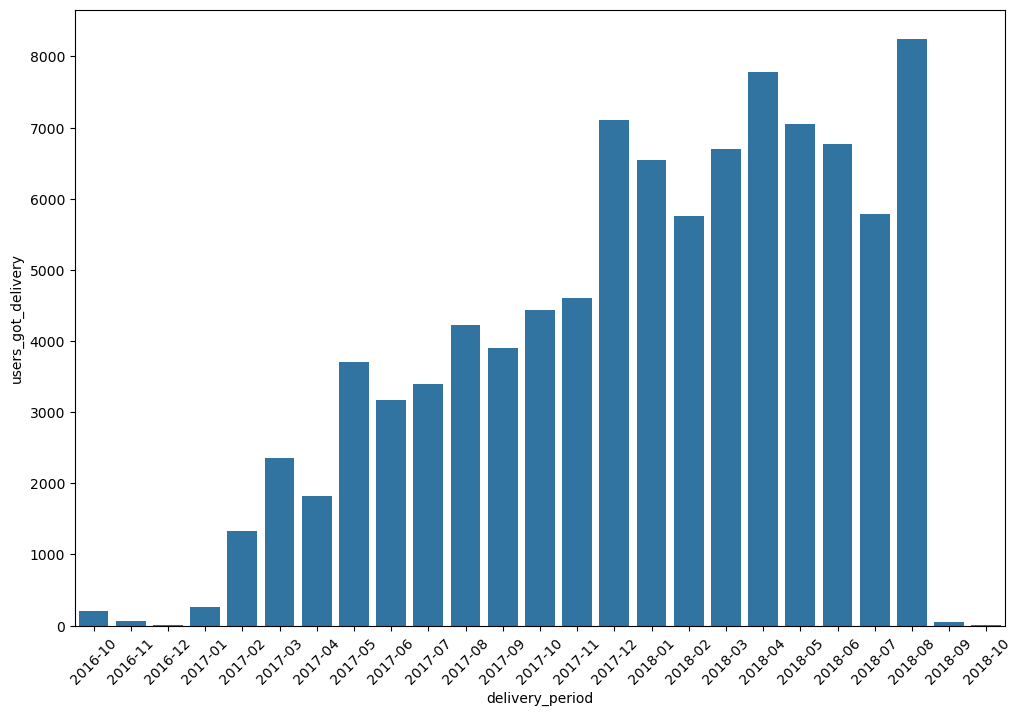

In [59]:
# рисуем график пользователей, получивших доставку
plt.figure(figsize=(12, 8))
sns.barplot(data=mdu, x ='delivery_period', y ='users_got_delivery')
plt.xticks(rotation=45)

### Третья — отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных).

В качестве такой метрики можно рассматривать коэффициент конверсии, чтобы понимать какой процент новых клиентов сделали нужное нам действие (например, оформили заказ или добавили товар в корзину)

### Четвёртая — отражать вовлеченность клиента в продолжение использования продукта.


Это метрика Customer Retention, ее считали в задаче 1

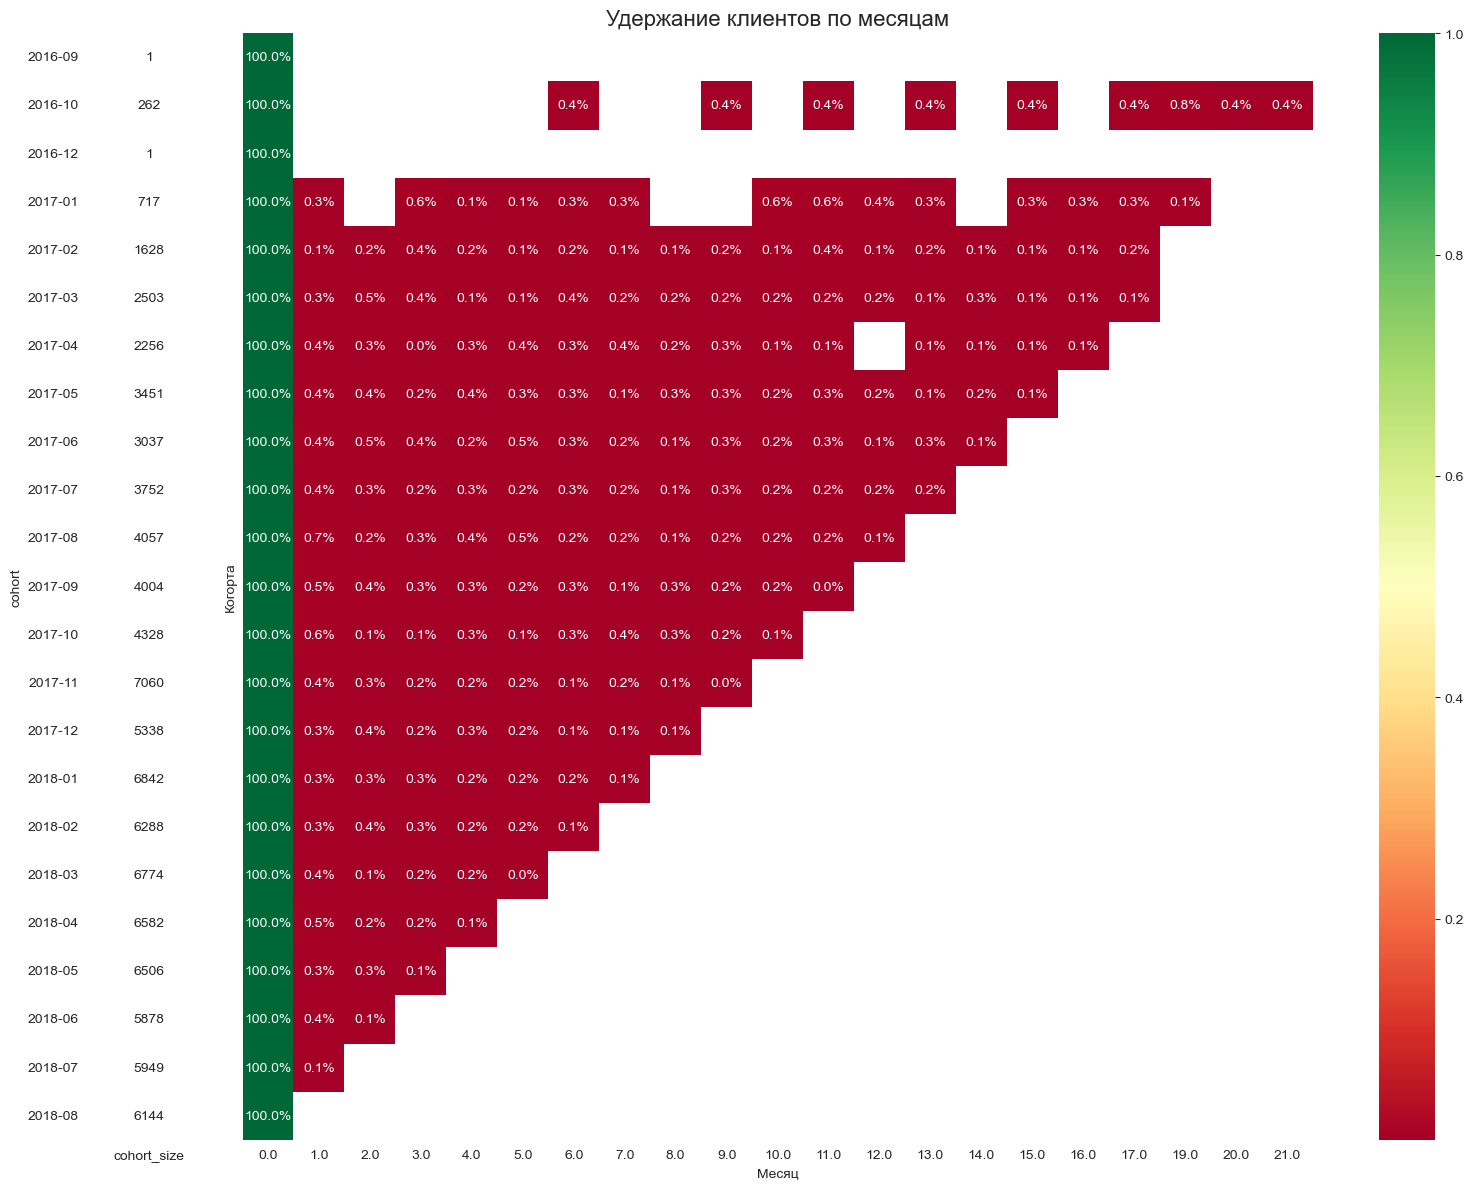

In [64]:
# Строим тепловую карту когортного анализа
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.1%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Удержание клиентов по месяцам', fontsize=16)
    ax[1].set(xlabel='Месяц', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

### Пятая — отражать денежное выражение вовлеченности клиента

В качестве метрики можно рассмотреть LTV клиента, чтобы понимать, сколько приносит один клиент за всё время взаимодействия с маркетплейсом, но так как у нас нет данных по переменным расходам, посчитатеть ее не можем  
Поэтому будем считать метрику **ARPU (Average Revenue Per User)**, так как она покажет, увеличивается или уменьшается сумма, на которую делают заказы потребители

In [67]:
arpu = pd.merge(revenue, mdu, left_on = 'payment_period', right_on = 'delivery_period', how = 'left')

In [68]:
# избавляемся от Nan
arpu.fillna(0, inplace=True)

C:\Users\elizawetavas\AppData\Local\Temp\ipykernel_20876\1483465203.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with period[M], please explicitly cast to a compatible dtype first.
  arpu.fillna(0, inplace=True)


In [69]:
# считаем arpu
arpu['arpu'] = arpu.all_revenue / arpu.users_got_delivery

In [70]:
arpu

,payment_period,revenue,d_revenue,all_revenue,delivery_period,users_got_delivery,arpu
0,2016-09,135.00,0.00,135.00,0,0.0,inf
1,2016-10,30389.70,5858.01,36247.71,2016-10,203.0,178.560148
2,2016-12,114.00,0.00,114.00,2016-12,4.0,28.500000
3,2017-01,85169.68,10893.35,96063.03,2017-01,264.0,363.875114
4,2017-02,195822.65,30132.36,225955.01,2017-02,1328.0,170.146845
5,2017-03,300031.00,37403.99,337434.99,2017-03,2354.0,143.345365
6,2017-04,259925.26,41060.98,300986.24,2017-04,1821.0,165.286238
7,2017-05,439977.96,52230.68,492208.64,2017-05,3699.0,133.065326
8,2017-06,364198.88,55139.18,419338.06,2017-06,3171.0,132.241583
9,2017-07,461508.90,54893.50,516402.40,2017-07,3403.0,151.749163


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, '2016-09'),
  Text(1, 0, '2016-10'),
  Text(2, 0, '2016-12'),
  Text(3, 0, '2017-01'),
  Text(4, 0, '2017-02'),
  Text(5, 0, '2017-03'),
  Text(6, 0, '2017-04'),
  Text(7, 0, '2017-05'),
  Text(8, 0, '2017-06'),
  Text(9, 0, '2017-07'),
  Text(10, 0, '2017-08'),
  Text(11, 0, '2017-09'),
  Text(12, 0, '2017-10'),
  Text(13, 0, '2017-11'),
  Text(14, 0, '2017-12'),
  Text(15, 0, '2018-01'),
  Text(16, 0, '2018-02'),
  Text(17, 0, '2018-03'),
  Text(18, 0, '2018-04'),
  Text(19, 0, '2018-05'),
  Text(20, 0, '2018-06'),
  Text(21, 0, '2018-07'),
  Text(22, 0, '2018-08'),
  Text(23, 0, '2018-09')])

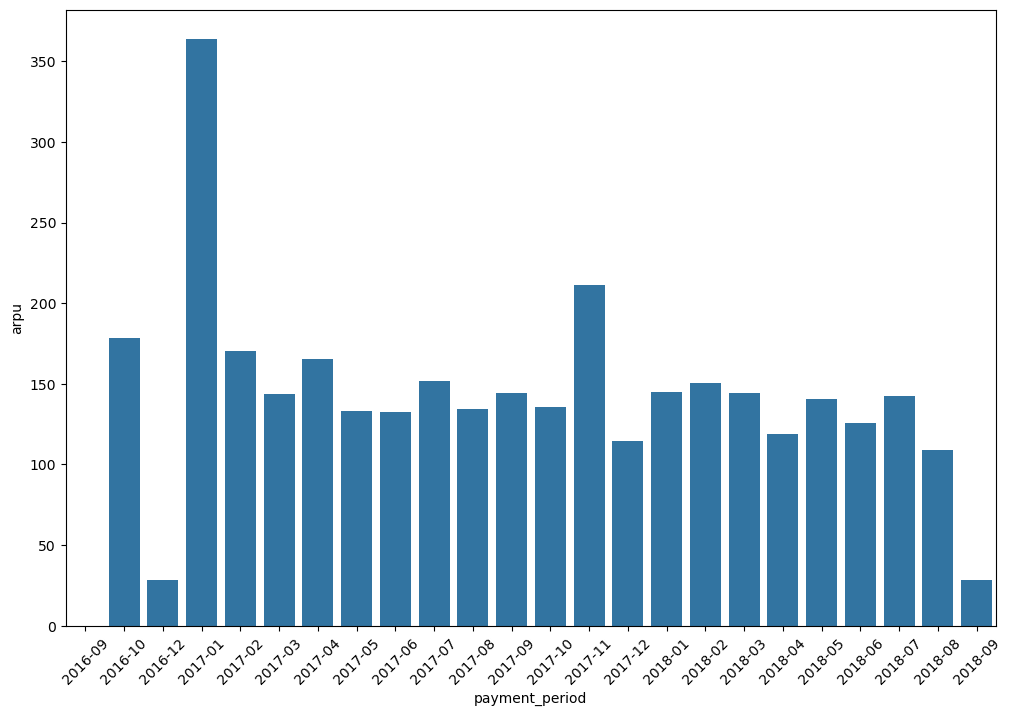

In [71]:
# рисуем график arpu
plt.figure(figsize=(12, 8))
sns.barplot(data=arpu, x ='payment_period', y ='arpu')
plt.xticks(rotation=45)

### Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.

Посмотрев с продактом на когортный анализ и метрики, вы решили, что нужно изменить продукт. Метрики необходимо срочно повышать. Вместе с командой вы сформулировали 3 гипотезы, в которые вы верите. По каждой гипотезе команда заполнила показатели по Ease, Confidence. Вам нужно заполнить самый важный показатель — Impact. Для этого вам требуется:

Выбрать одну из трёх основных гипотез с помощью фреймворка ICE, которые были сформированы продактом и, кажется, должны улучшить пользовательский опыт в маркетплейсе.

Для расчёта Impact возьмите данные с июня 2017 года. Считайте, что конверсия в повторный заказ равна величине медианного retention 1-го месяца (см. пункт 1 проекта).

Конверсия в повторный заказ 

In [74]:
median_1m

0.0035

#### Гипотеза 1
Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

In [76]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

In [77]:
# фильтруем заказы с июня 2017
orders_june2017 = orders[orders['order_purchase_timestamp'] >= '2017-06-01']

In [78]:
# считаем количество отмененных заказов
orders_unavailable_june2017 = orders_june2017.query('order_status == "unavailable"').order_id.count()
orders_canceled_june2017 = orders_june2017.query('order_status == "canceled"').order_id.count()
all_canceled_orders_june2017 = orders_unavailable_june2017 + orders_canceled_june2017
print("Если исправить баг в системе, то количество заказов увеличится на:", all_canceled_orders_june2017)

Если исправить баг в системе, то количество заказов увеличится на: 974


Для 974 заказов, метрика Impact по первой гипотезе составит 5.

In [80]:
# считаем баллдля первой гипотезы
ice_1 = 5 * 8 * 6
ice_1

240

#### Гипотеза 2
Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. 

In [82]:
# преобразуем даты
orders_june2017['order_delivered_customer_date'] = pd.to_datetime(orders_june2017['order_delivered_customer_date'])
orders_june2017['order_estimated_delivery_date'] = pd.to_datetime(orders_june2017['order_estimated_delivery_date'])

# заказы с задержкой
orders_june2017['is_delayed'] = orders_june2017['order_delivered_customer_date'] > orders_june2017['order_estimated_delivery_date']
delayed_orders_2017 = orders_june2017[orders_june2017['is_delayed']]

C:\Users\elizawetavas\AppData\Local\Temp\ipykernel_20876\362497363.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_june2017['order_delivered_customer_date'] = pd.to_datetime(orders_june2017['order_delivered_customer_date'])
C:\Users\elizawetavas\AppData\Local\Temp\ipykernel_20876\362497363.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_june2017['order_estimated_delivery_date'] = pd.to_datetime(orders_june2017['order_estimated_delivery_date'])
C:\Users\elizawetavas\AppData\Local\Temp\i

In [83]:
# чтобы знать, сколько клиентов вернутся, нам надо понимать количество УНИКАЛЬНЫХ КЛИЕНТОВ, поэтому объединяем таблицы
unique_customers_with_delayed_orders = delayed_orders_2017.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)


In [84]:
repeat_orders = unique_customers_with_delayed_orders.customer_unique_id.nunique() * median_1m

In [85]:
print(f"Если сократить время отгрузки заказа, то количество заказов увеличится на: {int(repeat_orders)}")

Если сократить время отгрузки заказа, то количество заказов увеличится на: 25


Для 25 заказов, метрика Impact по второй гипотезе составит 1. 

In [87]:
ice_2 = 1 * 10 * 4
ice_2

40

#### Гипотеза 3
Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.

In [89]:
# заказы с июня 2017 года объядинеям с таблицей по клиентам
unique_orders_june2017 = orders_june2017.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

In [90]:
# считаем по каждому уникальному пользователю, сколько заказов он сделал
orders_per_user = (unique_orders_june2017.groupby('customer_unique_id').agg(orders_cnt=('order_id', 'nunique')).reset_index())
orders_per_user.head()

,customer_unique_id,orders_cnt
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f6ccb0745a6a4b88665a16c9f078,1
3,0004aac84e0df4da2b147fca70cf8255,1
4,0004bd2a26a76fe21f786e4fbd80607f,1


In [91]:
# считаем, сколько людей не делали повторный заказ (сделали только 1 заказ)
one_order_users = orders_per_user[orders_per_user['orders_cnt'] == 1]
n_one_order_users = one_order_users.shape[0]
n_one_order_users

82559

In [92]:
new_clients = n_one_order_users * median_1m
print(f"Если cоздать новый способ оплаты, то количество заказов увеличится на: {int(new_clients)}")

Если cоздать новый способ оплаты, то количество заказов увеличится на: 288


Для 292 заказа, метрика Impact по третьей гипотезе составит 3. 

In [94]:
ice_3 = 3 * 5 * 9
ice_3 

135

**Выбор гипотезы**: самый большой ICE получился 240 у гипотезы 1. Значит, берем в работу ее

## Задача 5. Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.

После предыдущего исследования у вас появилась гипотеза, которую можно реализовать для значительного улучшения метрик компании. Вы предложили использовать A/B-тестирование для проверки её эффективности.

Продакт попросил вас:

Сформулировать метрики, на которые должна повлиять выбранная вами гипотеза.  
Сформулировать хотя бы по одной метрике в категории: целевые, прокси, guardrail и объяснить свой выбор.


## Выбранная гипотеза
Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

#### Метрики, на которые должна повлиять выбранная гипотеза
- количество доставленных заказов
- выручка от доставленных заказов
- коэффицент конверсии в доставку заказа

#### Целевые метрики
- количество доставленных заказов (это главная метрика, по которой мы сможем увидеть динамику доставленных заказов)
- выручка от доставленных заказов

#### Прокси метрики
- доля отмененных заказов (показывает, как много отмененных заказов в общем числе, если чисто увеличивается, это плохой знак)
- доля не оплаченных заказов / доля заказов, не переданных в логистическую службу (если эти показатели растут, то есть вероятность, что у нас увеличивается доля отмененных заказов)

#### Guardrail метрики
- среднее время доставки / время передачи в логистическую службу (если оно увеличилось, то есть вероятность, что мы не справляемся с масштабированием нашего бизнеса и не успевам вовремя отправить заказ клиенту)

## Задача 6. 

Сформулируйте выводы о проделанной работе и подготовьте небольшой, но логичный и содержательный отчет для Пети.

Структура должна выглядеть следующим образом:
- формализация проблемы продукта: что не так и как вы это поняли?

- общие выводы по итогу исследования на основе результатов, полученных в заданиях 1-5;

- рекомендации по продукту.

### Проблема продукта

- очень низкий retention rate на протяжении почти 2-х лет, и он никак не увеличивается
- большой уровень привлечения новых клиентов, которые не деляют повторные заказы (вероятно, на это тратятся большие маркетинговые бюджеты и LTV пользователя не превышает CPA)
- отсутствие product / market fit, так как клиенты не возвращаются

### Общие выводы по итогу исследования

- Выручка по результам 1-го года показывала рост, по результам 2-го года была примерно на одном уровне при разнонаправленной по месяцам динамике. В ноябре 2016 не было выручки вообще, возможно, в данных не хватает данных за этот период, где-то была допущена ошибка по сбору данных.
- Количество уникальных клиентов, получивших доставку, также за 2 года показывает рост, но по итогам последнего года в целом имеет сильно разнонаправленную динамику. Из интересного, в августе 2018 был всплеск доставок, но на выручку это сильно не повлияло.
- По ARPU за 2 года скорее убывающая тенденция, кроме периода января 2017, но так как выручка за этот месяц небольшая, то вероятно просто клиенты заказали более дорогостоящие товары.
- Большое количество клиентов появляется каждый месяц, но повторные заказы делают меньше 1% - и это большая проблема, с которой стоит работать в первую очередь, поскольку привлечение новых клиентов обычно обходится дороже, чем активирование старых. Потенциал роста есть не за счёт привлечения, а за счёт улучшения конверсии существующего спроса.
- Из 99 441 (orders) заказов доставлено было 96 478 (delivered_orders), а отменено только 974 заказа, поэтому проблема отмененных заказов, пожалуй, не является первостепенной. Основной вопрос - почему люди не возвращаются за товарами на маркетплейс.

### Рекомендации
- Провести исследование причин отсутствия повторных заказов у клиентов. Смутило ли их что-то в сервисе? Были ли какие-то неудобные моменты в процессе? Устраивает ли их ассортимент маркетплейса? Какие у них впечатления от товара, который был заказан? Выявить основные поинты, по которым клиенты не возвращаются и работать в ту сторону, потому что в целом первые заказы делают хорошо, это большие цифры, но потом клиент уже не видит для себя пользы от маркетплейса.
- Улучшить коммуникацию с пользователем при возникающих проблемах. Возможно, стоит отсмотреть рейтинг доставленных товаров, если там очень низкий рейтинг, то стоит обратить внимание на отзывы и пересматривать поставщиков. Если отзывы хорошие, то возможно стоит искать проблемы в сервисе ПВЗ / доставки.
- Провести конкурентный анализ. Может быть, у нас есть конкуренты, которые предлагают эти же товары сильно ниже, и когда клиент начинает задумываться о повторной покупке, он начинает сравнивать и заказывает тот же товар у других. Возможно, стоит даже проверить отсутствие утечек персональных данных о клиентах, потому что могут быть недобросовестные конкуренты, которые начинают маркетинговые кампании со спецпредложениями по данным наших клиентов.
- Подумать, как еще мы можем создать пользу для потребителя. Проанализировать товарную матрицу, может быть стоит добавить сопутствующие товары, которые увеличат средний чек. Или "товары из Бразилии" - это узкая сегментация и стоит ее расширить на "товары из Южной Америки"
- Рассмотреть retention по отдельным сегментам аудитории, возможно, для каких-то групп он будет выше, и нам стоит в первую очередь работать с группами с низким retention, и для каждой из них разработать свою стратегию стимулирования сбыта. В том числе особое внимание на пользователей, сделавших повторный заказ: кто эти люди? откуда они? есть ли у них схожие черты, благодаря которым их можно объединить в отдельный сегмент? + выяснить причины, по которым они совершили повторный заказ: возможно, у них были очень быстрые сроки доставки в первый раз?
- Исправить технические отмены заказов, поскольку это тоже создает негативный опыт и клиент уже не захочет возвращаться в маркетплейс, где заказ отменил не он сам.
- Не пытаться масштабироваться, пока не улучшится процент удержания клиентов